# How the segmentation network works, from pixels up

This notebook builds up the microhard segmentation model one idea at a time, on real
micrographs from the UHCS dataset. The plan:

1. look at the raw data and the question we are asking of it
2. try the dumbest possible classifier, to motivate learned features
3. see what convolutions and a pretrained encoder actually compute
4. understand what an untrained network outputs (and why it is not what it looks like)
5. compute the loss by hand
6. run the classic sanity check: overfit a single image
7. train for real, look at the errors, and connect pixels to hardness

Everything runs on the MacBook GPU. All code paths are the same ones the CLI uses;
the notebook just takes them apart. Cells depend on earlier cells, so run in order.

In [17]:
import os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from IPython.display import display

if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")  # notebook lives in notebooks/; work from the project root

from microhard.config import Config
from microhard.taxonomy import Taxonomy

torch.manual_seed(0)
cfg = Config.load("demo.toml")
taxonomy = Taxonomy.load(cfg.taxonomy_path)

device = cfg.resolve_device()
print("torch", torch.__version__, "| MPS available:", torch.backends.mps.is_available())
print("device:", device)
assert device.type == "mps", "this walkthrough expects the MacBook GPU"

torch 2.13.0 | MPS available: True
device: mps


## 1. The data and the question

The material is an ultrahigh carbon steel (about 2 wt% C, 4 wt% Cr). Depending on how it
was heat treated, carbon shows up in the microstructure in different forms: a continuous
cementite *network* along old grain boundaries, rounded *spheroidite* particles, lath-shaped
*Widmanstätten* cementite, all sitting in a ferritic *matrix*. Those forms control the
mechanical properties, which is why a metallographer stares at these images in the first
place.

The segmentation task: assign each pixel to one of those four constituents. We have 24
images where a human already did this (the DeCost benchmark), which is our ground truth.

In [2]:
from microhard.adapters.uhcs import SEG_CLASS_NODES, UHCSAdapter

adapter = UHCSAdapter(cfg, taxonomy)
records = adapter.validated_records()
masked = [r for r in records if r.mask_path is not None]
print(f"{len(records)} records, {len([r for r in records if r.image_path.exists()])} images on disk, "
      f"{len(masked)} with pixel labels")

rec = masked[0]
image = np.asarray(Image.open(rec.image_path).convert("RGB"))
gt = np.asarray(Image.open(rec.mask_path)).astype(np.int64)
print(rec.record_id, "| sample:", rec.group_id, "| scale:", rec.scale_um_per_px, "um/px")
print("mask class i means:", dict(enumerate(rec.mask_class_nodes)))

961 records, 163 images on disk, 24 with pixel labels
uhcs-6 | sample: uhcs-sample-29.0 | scale: 0.16129032258064516 um/px
mask class i means: {0: 'ferrous/matrix', 1: 'ferrous/network', 2: 'ferrous/spheroidite', 3: 'ferrous/widmanstatten'}


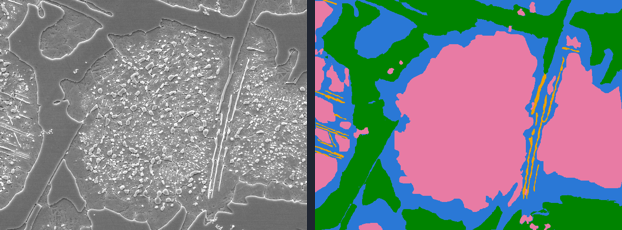

left: the SEM image. right: the human labels (blue matrix, green network, magenta spheroidite, yellow Widmanstätten)


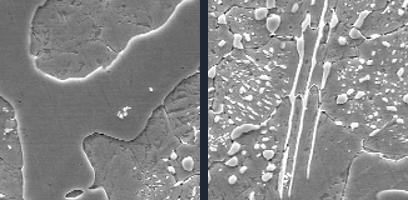

two 160px crops of the same image. the constituents differ mostly by texture and shape, not by brightness. keep that in mind for the next section.


In [3]:
# display helpers used throughout (PIL only, no plotting library)
COLORS = np.array([[42, 120, 214],   # 0 matrix        blue
                   [0, 131, 0],      # 1 network       green
                   [232, 123, 164],  # 2 spheroidite   magenta
                   [237, 161, 0]],   # 3 widmanstatten yellow
                  dtype=np.uint8)

def colorize(mask):
    return Image.fromarray(COLORS[mask])

def gray(a):
    a = np.asarray(a, dtype=np.float32)
    a = (a - a.min()) / (a.max() - a.min() + 1e-8)
    return Image.fromarray((a * 255).astype(np.uint8))

def row(*ims, h=230, gap=8):
    ims = [im.convert("RGB").resize((round(im.width * h / im.height), h)) for im in ims]
    out = Image.new("RGB", (sum(im.width for im in ims) + gap * (len(ims) - 1), h), "#202632")
    x = 0
    for im in ims:
        out.paste(im, (x, 0)); x += im.width + gap
    return out

display(row(Image.fromarray(image), colorize(gt)))
print("left: the SEM image. right: the human labels "
      "(blue matrix, green network, magenta spheroidite, yellow Widmanstätten)")

# zoom in on two constituents so the texture difference is visible
display(row(Image.fromarray(image[60:220, 60:220]), Image.fromarray(image[260:420, 380:540]), h=200))
print("two 160px crops of the same image. the constituents differ mostly by texture and shape, "
      "not by brightness. keep that in mind for the next section.")

An image is nothing exotic: a height-by-width-by-3 array of bytes. Since SEM images are
grayscale, the three channels are copies. Here is the actual distribution of pixel values.

In [4]:
print("shape:", image.shape, "dtype:", image.dtype, "min:", image.min(), "max:", image.max())

values = image[..., 0].ravel()
hist, edges = np.histogram(values, bins=16, range=(0, 256))
for count, lo, hi in zip(hist, edges[:-1], edges[1:]):
    bar = "#" * round(60 * count / hist.max())
    print(f"{int(lo):3d}-{int(hi):3d} {bar}")

shape: (484, 645, 3) dtype: uint8 min: 0 max: 255
  0- 16 
 16- 32 
 32- 48 
 48- 64 
 64- 80 #
 80- 96 ###
 96-112 #############################################
112-128 ###########################################################
128-144 ############################################################
144-160 ###################################
160-176 ################
176-192 ########
192-208 ######
208-224 #####
224-240 ####
240-256 #########


## 2. The dumbest classifier we can build

Before any neural network: can pixel brightness alone separate the four constituents?
Give the baseline every possible advantage. Use the ground truth itself to compute each
class's mean intensity on this very image, then label each pixel with the nearest class
mean. This is the ceiling for any brightness-threshold scheme, evaluated on its own
training data.

mean gray value per class: {'matrix': np.float32(130.2), 'network': np.float32(119.5), 'spheroidite': np.float32(157.3), 'widmanstatten': np.float32(204.3)}


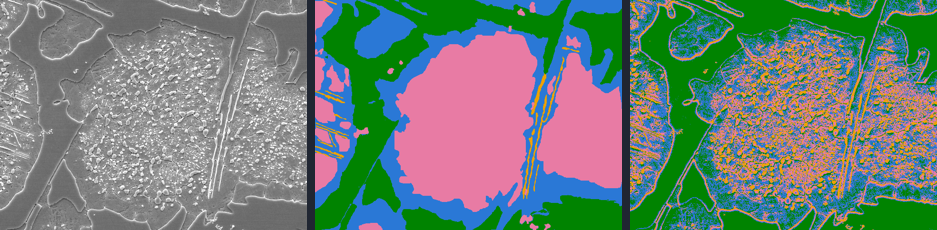

per-class IoU: {'matrix': 0.31, 'network': 0.52, 'spheroidite': 0.31, 'widmanstatten': 0.08}
mean IoU: 0.305


In [5]:
def iou_per_class(pred, target, n=4):
    out = {}
    for i in range(n):
        p, t = pred == i, target == i
        union = (p | t).sum()
        out[SEG_CLASS_NODES[i].split("/")[1]] = float((p & t).sum() / union) if union else None
    return out

g = image[..., 0].astype(np.float32)
class_means = np.array([g[gt == i].mean() for i in range(4)])
print("mean gray value per class:", dict(zip([n.split('/')[1] for n in SEG_CLASS_NODES],
                                             class_means.round(1))))

threshold_pred = np.abs(g[..., None] - class_means[None, None, :]).argmin(axis=-1)
display(row(Image.fromarray(image), colorize(gt), colorize(threshold_pred)))

scores = iou_per_class(threshold_pred, gt)
print("per-class IoU:", {k: (round(v, 2) if v is not None else None) for k, v in scores.items()})
print("mean IoU:", round(np.mean([v for v in scores.values() if v is not None]), 3))

It fails, and the class means printed above say why: the four constituents have nearly
the same average brightness. A spheroidite particle and a network branch are both
"cementite-colored"; what distinguishes them is shape and context, a round blob versus a
connected ridge, at a scale of tens of pixels. Any single-pixel rule is blind to that.
So we need features computed over neighborhoods. That is exactly what convolutions are.

## 3. What a convolution computes

A convolution slides a small weight grid over the image and takes dot products. Here is a
3x3 kernel that responds to vertical edges, written by hand.

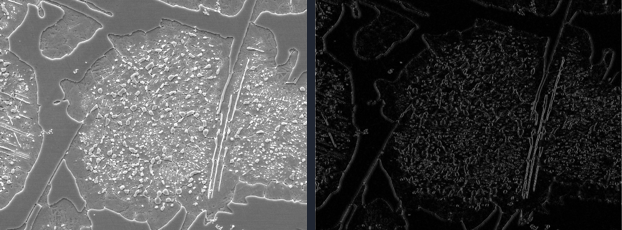

one hand-written kernel already highlights carbide boundaries. a network learns thousands of kernels like this, stacked in layers.


In [6]:
kernel = torch.tensor([[-1., 0., 1.],
                       [-2., 0., 2.],
                       [-1., 0., 1.]]).view(1, 1, 3, 3)  # Sobel x

g_t = torch.from_numpy(g).view(1, 1, *g.shape)
edges = F.conv2d(g_t, kernel, padding=1)[0, 0].numpy()
display(row(Image.fromarray(image), gray(np.abs(edges))))
print("one hand-written kernel already highlights carbide boundaries. "
      "a network learns thousands of kernels like this, stacked in layers.")

The encoder in this project is a resnet50 whose kernels were trained on 100k+
microscopy images (NASA's MicroNet). We keep it frozen: its features are treated as a
fixed measurement instrument, and only small task-specific heads train on top. Feed the
micrograph through and it returns a pyramid of feature maps, each stage halving the
resolution and roughly doubling the channels.

In [7]:
from microhard.backbone import build_encoder, freeze
from microhard.transforms import seg_eval_transforms

encoder = freeze(build_encoder(cfg)).to(device)
batch = seg_eval_transforms()(image=image)["image"].unsqueeze(0).to(device)
print("input:", tuple(batch.shape), "on", batch.device)

with torch.no_grad():
    pyramid = encoder(batch)
for depth, feats in enumerate(pyramid):
    px = 2 ** depth
    print(f"stage {depth}: {str(tuple(feats.shape)):22s} each unit summarizes ~{px}x{px} px of input")

input: (1, 3, 512, 672) on mps:0


stage 0: (1, 3, 512, 672)       each unit summarizes ~1x1 px of input
stage 1: (1, 64, 256, 336)      each unit summarizes ~2x2 px of input
stage 2: (1, 256, 128, 168)     each unit summarizes ~4x4 px of input
stage 3: (1, 512, 64, 84)       each unit summarizes ~8x8 px of input
stage 4: (1, 1024, 32, 42)      each unit summarizes ~16x16 px of input
stage 5: (1, 2048, 16, 21)      each unit summarizes ~32x32 px of input


stage 1 channels: edge and texture detectors, like our Sobel kernel but learned


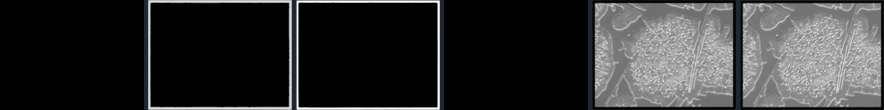

stage 4 channels: each unit sees a region the size of a whole constituent, and some channels light up on particle fields vs. network regions


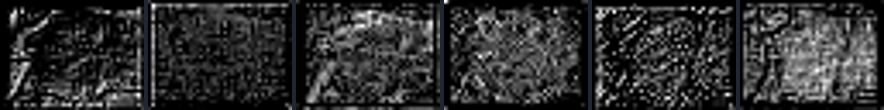

In [8]:
def show_channels(feats, n=6, h=110):
    f = feats[0].float().cpu()
    display(row(*[gray(f[c].numpy()) for c in range(n)], h=h, gap=4))

print("stage 1 channels: edge and texture detectors, like our Sobel kernel but learned")
show_channels(pyramid[1])
print("stage 4 channels: each unit sees a region the size of a whole constituent, "
      "and some channels light up on particle fields vs. network regions")
show_channels(pyramid[4])

## 4. The decoder, and what an untrained network actually predicts

The feature pyramid is spatially coarse at the deep end. A U-Net decoder walks back up:
upsample, concatenate the matching encoder stage (the skip connection, which restores
fine spatial detail), convolve, repeat. The final layer is a 1x1 convolution producing
four numbers per pixel, one score per constituent. The predicted class is the argmax.

Only the decoder trains. Parameter counts make the division of labor concrete.

In [9]:
from microhard.backbone import trainable_parameters
from microhard.segment import build_segmentation_model, segment_image

model = build_segmentation_model(cfg, num_classes=4).to(device)
frozen_n = sum(p.numel() for p in model.parameters() if not p.requires_grad)
train_n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"encoder (frozen):  {frozen_n/1e6:5.1f} M parameters")
print(f"decoder (trains):  {train_n/1e6:5.1f} M parameters")

with torch.no_grad():
    logits = model(batch)
print("output:", tuple(logits.shape), "= one score map per class, argmax over dim 1 per pixel")

encoder (frozen):   23.5 M parameters
decoder (trains):    9.0 M parameters


output: (1, 4, 512, 672) = one score map per class, argmax over dim 1 per pixel


Before training, what does this thing predict? A tempting guess is random static. The
truth is stranger and worth understanding, because the picture below is easy to misread.

the four probability maps of the untrained decoder (white = high):


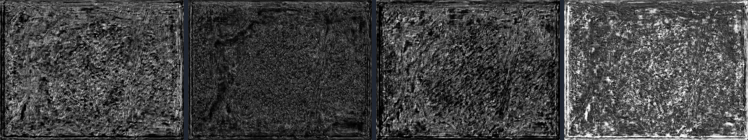

  P(       matrix)  mean 0.28  (chance level would be 0.25)
  P(      network)  mean 0.11  (chance level would be 0.25)
  P(  spheroidite)  mean 0.22  (chance level would be 0.25)
  P(widmanstatten)  mean 0.39  (chance level would be 0.25)

argmax of those maps:


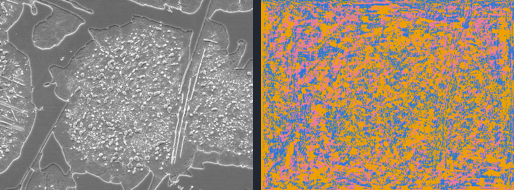

In [10]:
with torch.no_grad():
    probs = torch.softmax(model(batch), dim=1).squeeze(0).cpu()

untrained_pred = probs.argmax(dim=0).numpy()
h, w = image.shape[:2]
top, left = (untrained_pred.shape[0] - h) // 2, (untrained_pred.shape[1] - w) // 2
untrained_pred = untrained_pred[top:top+h, left:left+w]

print("the four probability maps of the untrained decoder (white = high):")
display(row(*[gray(probs[i].numpy()) for i in range(4)], h=140, gap=4))
for i, node in enumerate(SEG_CLASS_NODES):
    p = probs[i]
    print(f"  P({node.split('/')[1]:>13s})  mean {p.mean():.2f}  (chance level would be 0.25)")

print()
print("argmax of those maps:")
display(row(Image.fromarray(image), colorize(untrained_pred), h=190))

The probability maps are close to flat and close to chance. But convolution weights are
shared across the whole image, so whatever small preference the random initialization
gives one class, it gives it *everywhere*. Argmax then paints most of the frame in that
one arbitrary color. It looks like a confident (and absurd) prediction of a single
constituent; it is actually near-uniform uncertainty pushed through a winner-take-all
colormap.

The winning class is a coin flip. Re-initialize with different seeds and watch it change:

In [11]:
for seed in (0, 1, 2, 3):
    torch.manual_seed(seed)
    m = build_segmentation_model(cfg, num_classes=4)
    pred = segment_image(m, image, torch.device("cpu"))
    shares = np.bincount(pred.ravel(), minlength=4) / pred.size
    print(f"seed {seed}: " + "  ".join(f"{n.split('/')[1]}={s:5.1%}"
                                       for n, s in zip(SEG_CLASS_NODES, shares)))
torch.manual_seed(0)

seed 0: matrix= 0.0%  network=86.5%  spheroidite=12.9%  widmanstatten= 0.6%


seed 1: matrix=99.7%  network= 0.0%  spheroidite= 0.0%  widmanstatten= 0.3%


seed 2: matrix=46.9%  network=53.1%  spheroidite= 0.0%  widmanstatten= 0.0%


seed 3: matrix= 0.0%  network= 1.1%  spheroidite=98.9%  widmanstatten= 0.0%


One more thing to be explicit about, because the comparison strips later in this
notebook can be misread: **nothing here is generative**. A diffusion model starts from
sampled noise as its *input* and iteratively turns it into an image. This model is a
per-pixel classifier: the input is always the real micrograph, every prediction is a
single forward pass, and when a strip of images below goes from wrong to right, what
changed between panels is the *weights* (training progress), never the input.

## 5. The loss, computed by hand

Training needs a number that says how wrong the prediction is. Cross-entropy per pixel:
softmax the four scores into probabilities, then take minus the log of the probability
assigned to the true class. Let's do one pixel manually and check against the library.

In [12]:
y, x = 200, 300  # an arbitrary pixel
pixel_logits = logits[0, :, top + y, left + x].cpu()
manual_probs = torch.exp(pixel_logits) / torch.exp(pixel_logits).sum()
true_class = int(gt[y, x])
manual_loss = -torch.log(manual_probs[true_class])

lib_loss = F.cross_entropy(pixel_logits.unsqueeze(0), torch.tensor([true_class]))
print(f"pixel ({y},{x}): true class = {SEG_CLASS_NODES[true_class].split('/')[1]}")
print("logits:        ", pixel_logits.numpy().round(2))
print("softmax:       ", manual_probs.numpy().round(3))
print(f"manual -log p:  {manual_loss:.4f}")
print(f"F.cross_entropy {lib_loss:.4f}   (identical)")

pixel (200,300): true class = spheroidite
logits:         [-0.07  0.36  0.24  0.63]
softmax:        [0.17  0.26  0.231 0.34 ]
manual -log p:  1.4669
F.cross_entropy 1.4669   (identical)


In [13]:
# why we add a Dice term: the classes are far from balanced
counts = np.bincount(gt.ravel(), minlength=4)
for node, c in zip(SEG_CLASS_NODES, counts):
    print(f"{node.split('/')[1]:>13s}: {c:7d} px  ({c/gt.size:5.1%})")
print()
print("plain cross-entropy lets the model buy a low loss by nailing the majority classes")
print("and ignoring rare ones. Dice loss scores overlap per class, so a class is worth")
print("the same whether it covers 40% of the image or 4%. we train on the sum of both.")

       matrix:   87790 px  (28.1%)
      network:   87880 px  (28.2%)
  spheroidite:  132361 px  (42.4%)
widmanstatten:    4149 px  ( 1.3%)

plain cross-entropy lets the model buy a low loss by nailing the majority classes
and ignoring rare ones. Dice loss scores overlap per class, so a class is worth
the same whether it covers 40% of the image or 4%. we train on the sum of both.


## 6. Sanity check: overfit one image

A habit worth stealing from anyone who trains networks for a living: before training on
the dataset, train on a single example and make sure the loss goes to (near) zero. A
model that cannot memorize one image has a bug somewhere, and no amount of dataset-scale
training will fix it.

step   0  loss 2.453


step  10  loss 1.009


step  20  loss 0.657


step  30  loss 0.493


step  40  loss 0.398


step  50  loss 0.347


step  60  loss 0.309


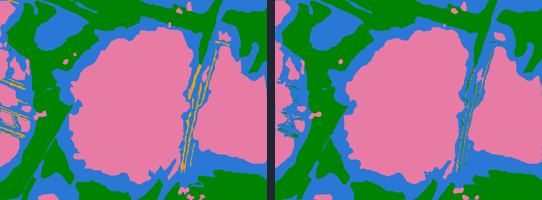

ground truth vs. the memorized prediction. per-class IoU: {'matrix': 0.91, 'network': 0.95, 'spheroidite': 0.96, 'widmanstatten': 0.15}
the machinery works. now the question becomes generalization.


In [14]:
import segmentation_models_pytorch as smp
from microhard.backbone import trainable_parameters

torch.manual_seed(0)
net = build_segmentation_model(cfg, num_classes=4).to(device)
dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
opt = torch.optim.AdamW(trainable_parameters(net), lr=1e-3)

gt_padded = np.zeros(batch.shape[-2:], dtype=np.int64)
gt_padded[top:top+h, left:left+w] = gt
target = torch.from_numpy(gt_padded).unsqueeze(0).to(device)

net.train(); net.encoder.eval()
for step in range(61):
    opt.zero_grad()
    out = net(batch)
    loss = dice(out, target) + F.cross_entropy(out, target)
    loss.backward()
    opt.step()
    if step % 10 == 0:
        print(f"step {step:3d}  loss {loss.item():.3f}")

memorized = segment_image(net, image, device)
display(row(colorize(gt), colorize(memorized), h=200))
overfit_iou = iou_per_class(memorized, gt)
print("ground truth vs. the memorized prediction. per-class IoU:",
      {k: (round(v, 2) if v is not None else None) for k, v in overfit_iou.items()})
print("the machinery works. now the question becomes generalization.")

## 7. Training for real

Now the actual training run, with one detail that matters more than any architecture
choice: the train/validation split is grouped by *physical sample*. Micrographs of the
same sample are near-duplicates, so putting some in train and some in validation would
let the model score well by recognition rather than understanding, and every number
after that would be quietly inflated.

The strips below show the same validation image (from a sample the model never trains
on) under the decoder's weights at different points in training. Same input every time;
only the weights differ between panels.

In [15]:
from torch.utils.data import DataLoader
from microhard.records import RecordSegmentationDataset, split_records_by_group
from microhard.segment import evaluate_segmentation
from microhard.transforms import seg_train_transforms

splits = split_records_by_group(masked, val_frac=0.2, test_frac=0.0, seed=cfg.seed)
train_recs, val_recs = splits["train"], splits["val"]
print(f"{len(train_recs)} train / {len(val_recs)} val images, "
      f"{len({r.group_id for r in train_recs})} vs {len({r.group_id for r in val_recs})} samples")

train_loader = DataLoader(RecordSegmentationDataset(train_recs, seg_train_transforms(cfg.image_size)),
                          batch_size=4, shuffle=True)
val_loader = DataLoader(RecordSegmentationDataset(val_recs, seg_eval_transforms()), batch_size=4)

val_rec = val_recs[0]
val_image = np.asarray(Image.open(val_rec.image_path).convert("RGB"))
val_gt = np.asarray(Image.open(val_rec.mask_path)).astype(np.int64)

torch.manual_seed(0)
net = build_segmentation_model(cfg, num_classes=4).to(device)
opt = torch.optim.AdamW(trainable_parameters(net), lr=cfg.lr)

snapshots = [segment_image(net, val_image, device)]  # epoch 0: untrained
for epoch in range(4):
    net.train(); net.encoder.eval()
    total = 0.0
    for images, masks_b in train_loader:
        images, masks_b = images.to(device), masks_b.to(device)
        opt.zero_grad()
        out = net(images)
        loss = dice(out, masks_b) + F.cross_entropy(out, masks_b)
        loss.backward()
        opt.step()
        total += loss.item() * len(images)
    miou = evaluate_segmentation(net, val_loader, device, 4)
    snapshots.append(segment_image(net, val_image, device))
    print(f"epoch {epoch+1}/4  loss {total/len(train_recs):.3f}  val mIoU {miou:.3f}")

17 train / 7 val images, 10 vs 2 samples


epoch 1/4  loss 2.124  val mIoU 0.072


epoch 2/4  loss 1.828  val mIoU 0.142


epoch 3/4  loss 1.614  val mIoU 0.281


epoch 4/4  loss 1.506  val mIoU 0.314


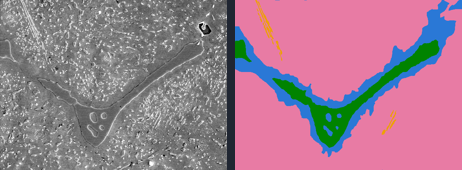

held-out input and its ground truth


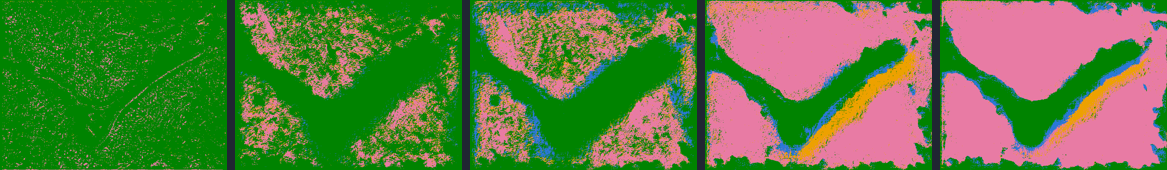

same input; decoder weights after 0, 1, 2, 3, 4 epochs of training


In [16]:
display(row(Image.fromarray(val_image), colorize(val_gt), h=170))
print("held-out input and its ground truth")
display(row(*[colorize(s) for s in snapshots], h=170))
print("same input; decoder weights after 0, 1, 2, 3, 4 epochs of training")

Structure emerges within a couple of epochs. The CLI run (`microhard train-seg`) did the
same thing for 14 epochs; load its checkpoint and score it properly.

In [17]:
from microhard.segment import load_segmenter

best, class_nodes = load_segmenter(cfg)
best.to(device)

# confusion matrix over the whole validation set
confusion = np.zeros((4, 4), dtype=np.int64)
per_image = []
for r in val_recs:
    im = np.asarray(Image.open(r.image_path).convert("RGB"))
    g_ = np.asarray(Image.open(r.mask_path)).astype(np.int64)
    p_ = segment_image(best, im, device)
    np.add.at(confusion, (g_.ravel(), p_.ravel()), 1)
    scores = iou_per_class(p_, g_)
    per_image.append((r, np.mean([v for v in scores.values() if v is not None])))

names = [n.split("/")[1][:6] for n in class_nodes]
print("confusion matrix, rows = truth, cols = predicted (thousands of px):")
print("        " + "".join(f"{n:>8s}" for n in names))
for i, name in enumerate(names):
    print(f"{name:>8s}" + "".join(f"{confusion[i, j]/1000:8.0f}" for j in range(4)))

print()
inter = np.diag(confusion)
union = confusion.sum(0) + confusion.sum(1) - inter
for name, i, u in zip(names, inter, union):
    print(f"IoU {name:>8s}: {i/u:.2f}")

confusion matrix, rows = truth, cols = predicted (thousands of px):
          matrix  networ  sphero  widman
  matrix     265      16      69       4
  networ      79     204       4       0
  sphero     225      31    1228      13
  widman       6       1      35       5

IoU   matrix: 0.40
IoU   networ: 0.61
IoU   sphero: 0.77
IoU   widman: 0.08


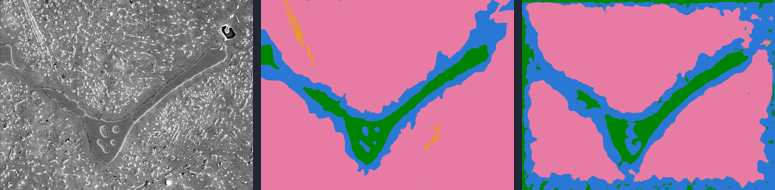

the worst validation image (uhcs-75, mIoU 0.41): input, truth, prediction.
the confusion matrix above says where the model struggles; typically the rarest
class (Widmanstätten) and boundaries between matrix and particle fields.


In [18]:
worst_rec, worst_miou = min(per_image, key=lambda t: t[1])
im = np.asarray(Image.open(worst_rec.image_path).convert("RGB"))
g_ = np.asarray(Image.open(worst_rec.mask_path)).astype(np.int64)
p_ = segment_image(best, im, device)
display(row(Image.fromarray(im), colorize(g_), colorize(p_), h=190))
print(f"the worst validation image ({worst_rec.record_id}, mIoU {worst_miou:.2f}): "
      "input, truth, prediction.")
print("the confusion matrix above says where the model struggles; typically the rarest")
print("class (Widmanstätten) and boundaries between matrix and particle fields.")

## 8. From pixels to a property

The point of segmenting was never the pretty mask. The mask collapses to a handful of
numbers per image (area fraction and region statistics per constituent), those numbers
are averaged over each sample's micrographs, and a small regression maps them to Vickers
hardness. Labels come from the Hecht thesis (7 samples so far, 410 to 876 HV).

In [19]:
from microhard.pipeline import predict_image

result = predict_image(cfg, val_rec.image_path, family="ferrous")
for node, frac in result.fractions.items():
    print(f"{node:<24s} {'#' * round(frac * 40):<40s} {frac:6.1%}")
print()
print("properties:", {k: round(v) for k, v in result.properties.items()})
print("abstentions:", result.abstentions or "none")

ferrous/matrix           ##########                                25.5%
ferrous/network          ####                                       9.4%
ferrous/spheroidite      ##########################                65.0%
ferrous/widmanstatten                                               0.1%

properties: {'hardness_hv': 619}
abstentions: none


The current fit is weak: leave-one-sample-out MAE is about 123 HV on n=7. That number
has a physical explanation rather than a mysterious one. In this steel, hardness is set
mostly by the *matrix* state (martensite vs. pearlite vs. bainite, decided by cooling
rate; Hecht's thesis reaches the same conclusion via pearlite spacing). Our four classes
lump all of those into a single "matrix" label, so two treatments 200 HV apart can
produce nearly identical fraction vectors. A model cannot recover information its
features never contained. The interesting consequence: the image-level constituent
classifier in this repo *does* have a martensite class, and wiring its output into the
feature vector is the obvious next experiment.

## Things to try

- Rerun section 7 with `encoder_weights = "imagenet"` in demo.toml and compare val mIoU
  against the MicroNet encoder. How much do microscopy-pretrained features buy?
- Unfreeze the last encoder stage (set `requires_grad_(True)` on
  `net.encoder.layer4`) with a 10x smaller learning rate. Does val mIoU beat 0.495?
- Add the 7-class constituent classifier's prediction as features in
  `features.py` and refit hardness. Does the FC vs. WQ confusion resolve?
- Fetch all 961 micrographs (`python scripts/fetch_uhcs_mirror.py --all`) and extend
  the hardness table beyond n=7 if you can source more measurements.

| notebook section | CLI equivalent |
|---|---|
| section 7 training | `uv run microhard train-seg -c demo.toml` |
| section 8 features + fit | `uv run microhard extract-features && uv run microhard fit-hardness` |
| section 8 prediction | `uv run microhard predict <image> --family ferrous -c demo.toml` |